# Fig. 1 — Typical daily forcing (ALBA, Casagli et al. 2021)

Visual check of **control points + cubic spline** curves from `bioprocess_twin.forcing.typical_daily_forcing_per_season`.

- **Three cells below:** each produces **one** of the three panels (irradiance, temperature, evaporation rate).
- Continuous lines: dense grid (200 points over 0–24 h). Optional markers: spline knots from the paper figure.
- Hourly table for the simulator: `t_h = 0 … 23` from the same splines (see `data/forcing/typical_daily_patterns_of_temperature_irradiance_and_evaporation_rates.csv`).

**Kernel:** use the project virtualenv (`.venv`) so `import bioprocess_twin` resolves.

In [22]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np

from bioprocess_twin.forcing import typical_daily_forcing_per_season as fig1

seasons = ("spring", "summer", "autumn", "winter")
t_smooth = fig1.dense_time_grid(200)

print(fig1.__file__)

/home/anibal/projects/active/bioprocess-twin-hub/src/bioprocess_twin/forcing/typical_daily_forcing_per_season.py


## Panel 1 — Irradiance

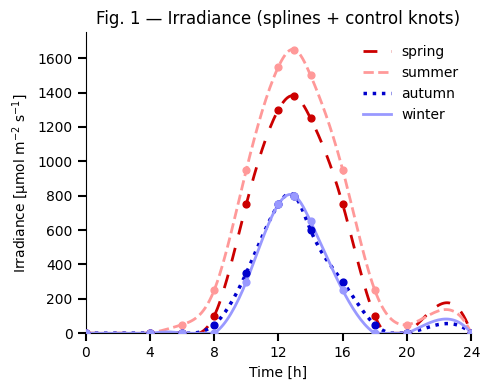

In [23]:
fig, ax = plt.subplots(figsize=(5, 4))
for season in seasons:
    irr, _, _ = fig1.evaluate_forcing(season, t_smooth)
    sty = fig1.FIG1_LINE_STYLES[season]
    ax.plot(t_smooth, irr, label=season, **sty)
    ax.scatter(
        fig1.T_CTRL_IRR,
        fig1.IRRADIANCE_CONTROL[season],
        color=sty["color"],
        s=24,
        zorder=5,
        marker="o",
    )
ax.set_ylabel(r"Irradiance [µmol m$^{-2}$ s$^{-1}$]")
ax.set_xlabel("Time [h]")
ax.set_xlim(0, 24)
ax.set_ylim(0, 1750)
ax.set_xticks(np.arange(0, 25, 4))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", direction="out", length=6, width=1.5)
ax.legend(loc="upper right", frameon=False)
ax.set_title("Fig. 1 — Irradiance (splines + control knots)")
plt.tight_layout()
plt.show()

## Panel 2 — Temperature

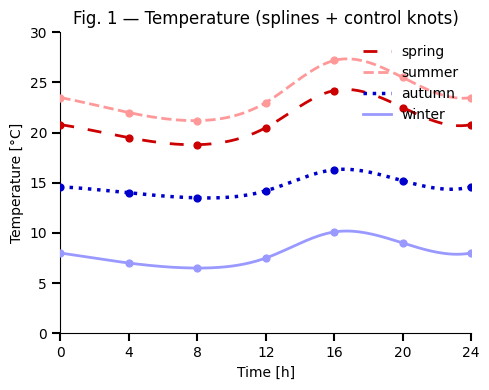

In [24]:
fig, ax = plt.subplots(figsize=(5, 4))
for season in seasons:
    _, temp, _ = fig1.evaluate_forcing(season, t_smooth)
    sty = fig1.FIG1_LINE_STYLES[season]
    ax.plot(t_smooth, temp, label=season, **sty)
    ax.scatter(
        fig1.T_CTRL_TEMP,
        fig1.TEMPERATURE_CONTROL[season],
        color=sty["color"],
        s=24,
        zorder=5,
        marker="o",
    )
ax.set_ylabel("Temperature [°C]")
ax.set_xlabel("Time [h]")
ax.set_xlim(0, 24)
ax.set_ylim(0, 30)
ax.set_xticks(np.arange(0, 25, 4))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", direction="out", length=6, width=1.5)
ax.legend(loc="upper right", frameon=False)
ax.set_title("Fig. 1 — Temperature (splines + control knots)")
plt.tight_layout()
plt.show()

## Panel 3 — Evaporation rate

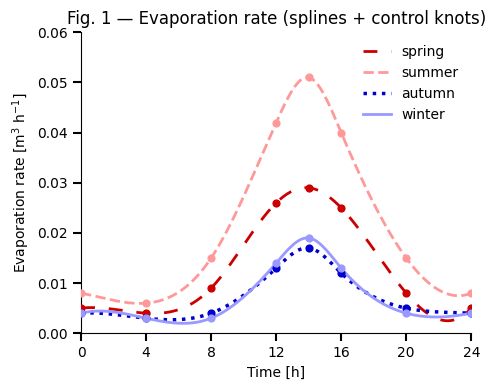

In [25]:
fig, ax = plt.subplots(figsize=(5, 4))
for season in seasons:
    _, _, evap = fig1.evaluate_forcing(season, t_smooth)
    sty = fig1.FIG1_LINE_STYLES[season]
    ax.plot(t_smooth, evap, label=season, **sty)
    ax.scatter(
        fig1.T_CTRL_EVAP,
        fig1.EVAPORATION_CONTROL[season],
        color=sty["color"],
        s=24,
        zorder=5,
        marker="o",
    )
ax.set_ylabel(r"Evaporation rate [m$^3$ h$^{-1}$]")
ax.set_xlabel("Time [h]")
ax.set_xlim(0, 24)
ax.set_ylim(0, 0.06)
ax.set_xticks(np.arange(0, 25, 4))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", direction="out", length=6, width=1.5)
ax.legend(loc="upper right", frameon=False)
ax.set_title("Fig. 1 — Evaporation rate (splines + control knots)")
plt.tight_layout()
plt.show()

## Hourly sampling (simulator output)

Same values as in `typical_daily_patterns_of_temperature_irradiance_and_evaporation_rates.csv`: **24 rows per season**, `t_h = 0 … 23`. Example: summer, first 12 h.

,season,t_h,irradiance_umol_m2_s,temperature_C,evaporation_m3_h
24,summer,0.0,0.000000e+00,23.500000,0.008000
25,summer,1.0,0.000000e+00,23.148828,0.007283
26,summer,2.0,0.000000e+00,22.764732,0.006556
27,summer,3.0,0.000000e+00,22.373270,0.006050
28,summer,4.0,1.776357e-15,22.000000,0.006000
29,summer,5.0,2.209440e+01,21.670480,0.006637
30,summer,6.0,5.000000e+01,21.410268,0.008194
31,summer,7.0,9.880456e+01,21.244922,0.010904
32,summer,8.0,2.500000e+02,21.200000,0.015000
33,summer,9.0,5.639374e+02,21.305190,0.020591


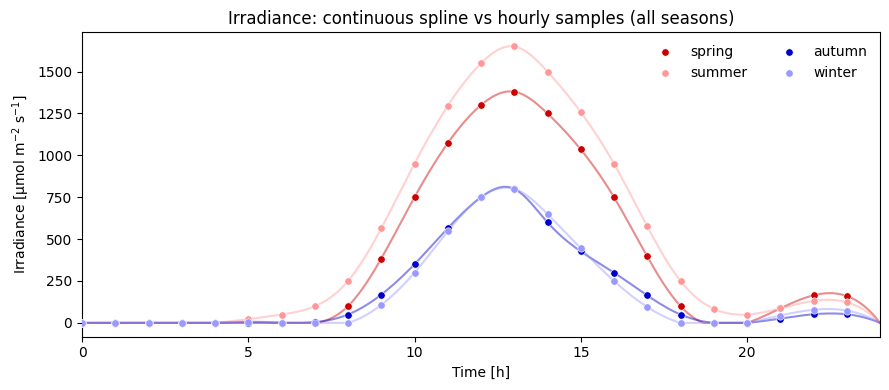

In [26]:
from IPython.display import display

df = fig1.typical_daily_forcing_table()
display(df[df["season"] == "summer"].head(12))

t_h = fig1.hourly_array_t_h()
fig, ax = plt.subplots(figsize=(9, 4))
for season in seasons:
    irr, _, _ = fig1.evaluate_forcing(season, t_smooth)
    irr_h, _, _ = fig1.evaluate_forcing(season, t_h)
    c = fig1.FIG1_LINE_STYLES[season]["color"]
    ax.plot(t_smooth, irr, color=c, alpha=0.45)
    ax.scatter(t_h, irr_h, color=c, s=28, label=season, zorder=5, edgecolors="white", linewidths=0.4)
ax.set_xlabel("Time [h]")
ax.set_ylabel(r"Irradiance [µmol m$^{-2}$ s$^{-1}$]")
ax.set_title("Irradiance: continuous spline vs hourly samples (all seasons)")
ax.legend(loc="upper right", frameon=False, ncol=2)
ax.set_xlim(0, 24)
plt.tight_layout()
plt.show()